In [1]:
# ======================================================================
# CELL 1 — Connect to WRDS
# ======================================================================
import wrds
import pandas as pd
import warnings
import os

os.chdir('/Users/connorbrennan/Library/CloudStorage/OneDrive-TheUniversityofChicago/Research/monetary_unertainty_spillovers/data/raw_data/consensus_econ')

warnings.filterwarnings('ignore')

db = wrds.Connection()
print('Connected to WRDS.')

# ======================================================================
# CELL 2 — Config
# ======================================================================
ECON_LIB = 'tr_ds_econ'
INFO_TABLE = 'wrds_ecoinfo'
TS_TABLE = 'ecodata'

# ======================================================================
# CELL 3 — Download series metadata
# ======================================================================
print('Downloading series metadata...')
all_info = db.get_table(library=ECON_LIB, table=INFO_TABLE)
print(f'Total series: {len(all_info):,}')
all_info.head(3)

# ======================================================================
# CELL 4 — Search for Consensus CPI forecast series
# ======================================================================
def search_series(df, keywords):
    cols = df.select_dtypes(include='object').columns.tolist()
    combined = df[cols].fillna('').astype(str).agg(' '.join, axis=1).str.lower()
    mask = pd.Series(True, index=df.index)
    for kw in keywords:
        mask &= combined.str.contains(kw.lower(), na=False)
    return df[mask].copy()

# Strategy 1: search descriptions
consensus_cpi = search_series(all_info, ['consensus', 'consumer price'])
if len(consensus_cpi) == 0:
    consensus_cpi = search_series(all_info, ['conprc'])
if len(consensus_cpi) == 0:
    consensus_cpi = search_series(all_info, ['consensus', 'inflation'])
if len(consensus_cpi) == 0:
    consensus_cpi = search_series(all_info, ['consensus', 'cpi'])

# Strategy 2: search by known mnemonic patterns
patterns = ['CONPRCF', 'CONPRC', 'CNCPI', 'CONCPI', 'CONPRCE', 'CECPR']
mnem_mask = pd.Series(False, index=all_info.index)
for p in patterns:
    mnem_mask |= all_info['dsmnemonic'].astype(str).str.contains(p, case=False, na=False)
consensus_by_mnem = all_info[mnem_mask]

# Combine
target = pd.concat([consensus_cpi, consensus_by_mnem]).drop_duplicates(subset='ecoseriesid')
print(f'Found {len(target)} Consensus CPI series')
print(f'\nSample mnemonics & descriptions:')
print(target[['dsmnemonic', 'mktdesc', 'desc_english', 'isforecast']].head(20).to_string(index=False))

# ======================================================================
# CELL 5 — Preview: list all found series by country
# ======================================================================
print(f'\nAll {len(target)} series by country:\n')
for _, row in target.sort_values('mktdesc').iterrows():
    print(f"  {row['dsmnemonic']:20s} | {row['mktdesc']:20s} | forecast={row['isforecast']} | {row['desc_english'][:60]}")

# ======================================================================
# CELL 6 — Pull time series data via JOIN
# ======================================================================
# The ecodata table uses ecoseriesid (not mnemonics), so we JOIN
series_ids = target['ecoseriesid'].dropna().unique().tolist()
print(f'Querying {len(series_ids)} series IDs...')

all_data = []
batch_size = 100

for i in range(0, len(series_ids), batch_size):
    batch = series_ids[i:i+batch_size]
    placeholders = ','.join([str(int(s)) for s in batch])
    q = f"""
        SELECT d.ecoseriesid, d.perioddate, d.series_value,
               d.announceddate, d.changeseq,
               i.dsmnemonic, i.mktdesc, i.desc_english,
               i.isforecast, i.freqcode, i.unitcodedesc
        FROM {ECON_LIB}.{TS_TABLE} d
        INNER JOIN {ECON_LIB}.{INFO_TABLE} i
            ON d.ecoseriesid = i.ecoseriesid
        WHERE d.ecoseriesid IN ({placeholders})
        ORDER BY d.ecoseriesid, d.perioddate, d.changeseq
    """
    try:
        chunk = db.raw_sql(q)
        all_data.append(chunk)
        print(f'  Batch {i//batch_size+1}: {len(chunk):,} rows')
    except Exception as e:
        print(f'  Batch {i//batch_size+1} error: {e}')

df_raw = pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
print(f'\nTotal rows: {len(df_raw):,}')
if len(df_raw) > 0:
    print(f'Unique series: {df_raw["dsmnemonic"].nunique()}')
    print(f'Unique countries: {df_raw["mktdesc"].nunique()}')
    df_raw.head()

# ======================================================================
# CELL 7 — Keep only the latest revision for each series × date
# ======================================================================
# ecodata stores multiple revisions (changeseq). Keep the latest.
if len(df_raw) > 0:
    df = (df_raw
          .sort_values(['ecoseriesid', 'perioddate', 'changeseq'])
          .drop_duplicates(subset=['ecoseriesid', 'perioddate'], keep='last')
          .copy())
    df['perioddate'] = pd.to_datetime(df['perioddate'], errors='coerce')
    df['series_value'] = pd.to_numeric(df['series_value'], errors='coerce')
    print(f'After dedup: {len(df):,} rows (from {len(df_raw):,})')

# ======================================================================
# CELL 8 — Enrich with country names
# ======================================================================
DS_COUNTRY = {
    'UNITED STATES': 'United States', 'UNITED KINGDOM': 'United Kingdom',
    'JAPAN': 'Japan', 'GERMANY': 'Germany', 'FRANCE': 'France',
    'ITALY': 'Italy', 'CANADA': 'Canada', 'EMU': 'Eurozone',
    'EURO AREA': 'Eurozone', 'EUROZONE': 'Eurozone',
    'AUSTRALIA': 'Australia', 'SWITZERLAND': 'Switzerland',
    'SWEDEN': 'Sweden', 'NORWAY': 'Norway', 'DENMARK': 'Denmark',
    'NETHERLANDS': 'Netherlands', 'BELGIUM': 'Belgium', 'SPAIN': 'Spain',
    'PORTUGAL': 'Portugal', 'IRELAND': 'Ireland', 'GREECE': 'Greece',
    'AUSTRIA': 'Austria', 'FINLAND': 'Finland',
    'SOUTH KOREA': 'South Korea', 'KOREA': 'South Korea',
    'TAIWAN': 'Taiwan', 'HONG KONG': 'Hong Kong',
    'SINGAPORE': 'Singapore', 'THAILAND': 'Thailand',
    'INDONESIA': 'Indonesia', 'MALAYSIA': 'Malaysia',
    'PHILIPPINES': 'Philippines', 'INDIA': 'India',
    'NEW ZEALAND': 'New Zealand', 'CHINA': 'China',
    'BRAZIL': 'Brazil', 'MEXICO': 'Mexico', 'ARGENTINA': 'Argentina',
    'CHILE': 'Chile', 'COLOMBIA': 'Colombia', 'PERU': 'Peru',
    'POLAND': 'Poland', 'CZECH REPUBLIC': 'Czech Republic',
    'HUNGARY': 'Hungary', 'RUSSIA': 'Russia', 'TURKEY': 'Turkey',
    'SOUTH AFRICA': 'South Africa', 'ISRAEL': 'Israel',
    'NIGERIA': 'Nigeria', 'EGYPT': 'Egypt', 'SAUDI ARABIA': 'Saudi Arabia',
    'WORLD': 'World',
}

if len(df_raw) > 0:
    df['country'] = df['mktdesc'].str.strip().str.upper().map(DS_COUNTRY)
    df['country'] = df['country'].fillna(df['mktdesc'].str.title())
    df = df.sort_values(['dsmnemonic', 'perioddate']).reset_index(drop=True)

    print(f'Rows: {len(df):,} | Unique series: {df["dsmnemonic"].nunique()} | Countries: {df["country"].nunique()}')
    print(f'Date range: {df["perioddate"].min()} → {df["perioddate"].max()}')
    print(f'\nSeries per country:')
    print(df.groupby('country')['dsmnemonic'].nunique().sort_values(ascending=False).to_string())

# ======================================================================
# CELL 9 — Pivot to wide format (date × mnemonic)
# ======================================================================
if len(df_raw) > 0:
    # Wide by mnemonic (preserves all series/horizons)
    df_wide_mnem = df.pivot_table(
        index='perioddate', columns='dsmnemonic',
        values='series_value', aggfunc='first'
    )
    df_wide_mnem.index.name = 'date'
    print(f'Wide (by mnemonic): {df_wide_mnem.shape[0]} dates × {df_wide_mnem.shape[1]} series')

    # Wide by country (takes first series per country — mainly useful for plotting)
    df_wide_country = df.pivot_table(
        index='perioddate', columns='country',
        values='series_value', aggfunc='first'
    )
    df_wide_country.index.name = 'date'
    print(f'Wide (by country):  {df_wide_country.shape[0]} dates × {df_wide_country.shape[1]} countries')
    df_wide_country.tail(10)




WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Connected to WRDS.
Total series: 210,795
Found 203 Consensus CPI series

Sample mnemonics & descriptions:
dsmnemonic              mktdesc                         desc_english isforecast
  ALCECPRM              ALBANIA         CONSUMER PRICES (%YOY, MEAN)          0
  NLCACPRS          NETHERLANDS        CONSUMER PRICES (%YOY, STDEV)          0
 BDCONPRCE              GERMANY                        CPI (CAL ADJ)          0
 CNCONPRCF               CANADA                                  CPI          0
 CNCONPRCE               CANADA            CPI (SEASONALLY ADJUSTED)          0
 FRCONPRCE               FRANCE                                  CPI          0
 EDCONPRCF              ECUADOR                                  CPI          0
 NWCONPRCE               NORWAY                 CONSUMER PRIC

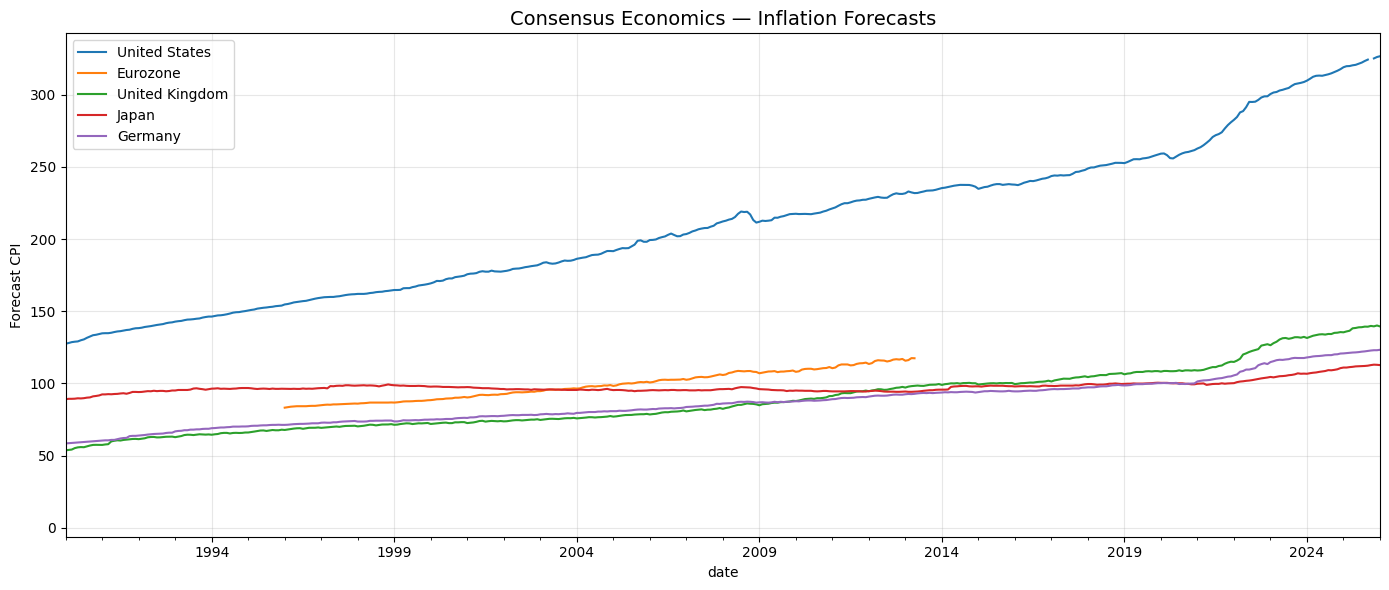

In [9]:
# ======================================================================
# CELL 10 — Plot major economies
# ======================================================================
import matplotlib.pyplot as plt

if len(df_raw) > 0:
    major = ['United States', 'Eurozone', 'United Kingdom', 'Japan', 'Germany']
    cols = [c for c in major if c in df_wide_country.columns]
    if not cols:
        cols = df_wide_country.columns[:5].tolist()

    fig, ax = plt.subplots(figsize=(14, 6))
    df_wide_country[cols].dropna(how='all').plot(ax=ax, lw=1.5, xlim=(df_wide_country.index.min() + pd.DateOffset(years=77), df_wide_country.index.max()))
    ax.set_title('Consensus Economics — Inflation Forecasts', fontsize=14)
    ax.set_ylabel('Forecast CPI')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [3]:
# ======================================================================
# CELL 11 — Export
# ======================================================================
if len(df_raw) > 0:
    # Long format — all detail preserved
    df.to_csv('consensus_cpi_forecasts_long.csv', index=False)
    print(f'Saved: consensus_cpi_forecasts_long.csv ({len(df):,} rows)')

    # Wide by mnemonic
    df_wide_mnem.to_csv('consensus_cpi_forecasts_wide_mnemonic.csv')
    print(f'Saved: consensus_cpi_forecasts_wide_mnemonic.csv')

    # Wide by country
    df_wide_country.to_csv('consensus_cpi_forecasts_wide_country.csv')
    print(f'Saved: consensus_cpi_forecasts_wide_country.csv')
else:
    print('No data to export.')

# ======================================================================
# CELL 12 — Close connection
# ======================================================================
# db.close()
print('Done.')

Saved: consensus_cpi_forecasts_long.csv (70,773 rows)
Saved: consensus_cpi_forecasts_wide_mnemonic.csv
Saved: consensus_cpi_forecasts_wide_country.csv
Done.


# Testing stuff

In [4]:
db.close()